* You can use as many cells as you need to answer the questions.
* Answer any questions in a markup cell.
* Plots should have labels on the axes, legends if appropriate etc.


In [23]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# Adjust default font size so that labels are readable in plots
font = {'size': 18}
matplotlib.rc('font', **font)
matplotlib.rcParams['savefig.dpi'] = 200
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = [6, 4]

# Q1

Suppose that there is an outbreak of a deadly disease - for example, perhaps avian flu has hopped to humans. Your doctor has just told you that you have tested positive for this disease. For people <mark>with the disease, the test is correct 90\% of the time</mark>. He also mentions that the disease is prevalent in the general population at a rate of <mark>0.1\%</mark> and that the <mark>false positive rate for the test is 1\%</mark>.

Should you worry? Explain your reasoning quantitatively.

Recall Bayes' Theorem 

\begin{equation*}
P(A|B) = \frac{P(B|A) P(A)}{P(B)}
\end{equation*}

and let $A = $ Actually sick and $B = $ Test positive. Such that $P(B|A) = 0.9$, $P(A) = 0.001$, and $P(B|A') = 0.01 $ (false positive)

By the law of total probability we get $P(B)$:
\begin{equation*}
P(B) = P (B|A) P(A) + P(B|A')P(A') = (0.9)(0.001) + (0.01)(1 - 0.001) = 0.01089
\end{equation*}

which we can then use to compute the probability that we are truly sick given that we tested positive.: 

\begin{equation*}
P(A|B) = \frac{P(B|A) P(A)}{P(B)} = \frac{(0.9)(0.001)}{(0.01089)} = 0.0826446281 \approx \boxed{8.3\%}
\end{equation*}

Despite the positive test, the probability of actually having the disease is only about $8.3\%$. Because the disease is rare to begin with, false positives outnumber true positives and the positive result therefore does not make infection likely. Although it raises the probability substantially from the initial $0.1\%$, which would *personally* make me worry.

# Q2

Experimental design: In the original HST guide star catalogue (created based on ground-based data), 60\% of the catalogue "objects" are actually binary stars. These are bad for guiding.

How large a sample of $N$ catalogue objects should be chosen to ensure that the probability that at least <mark>two sample objects are non-binary</mark> stars is at least <mark>99\%</mark>?

## a) 
Write down an analytic expression for $N$. Then solve it analytically or numerically.


We are given $P(\rm Binary) = 0.6$ and $P(\rm Non-Binary) = 0.4$, since we are looking for non-binary stars (indep trials that either succeed or fail) this is a binomial distribution with success probability $p = 0.4$ and failure probability $q = 0.6$. Looking for $N \geq 2$ at $99\%$ chance, and let $X$ be the number of NB stars: 
\begin{equation*}
P(X \geq 2) \geq 0.99
\end{equation*}
we can compute as the total probability ($1$) - the odds of getting $1$ and $0$ NB stars: 
\begin{equation*}
P(X \geq 2) = 1 - P(X=1) - P(X=0)
\end{equation*}
we can compute $P(X=1)$ and $P(X=0)$ with the binomial formula: 
\begin{equation*}
P(X = k) = \frac{N!}{k!(N-1)!}p^{k}q^{N-k} 
\end{equation*}
such that 
\begin{equation*}
P(X = 0) = \frac{N!}{0!(N-1)!}(0.4)^{0}(0.6)^{N-0} = (0.6)^N
\end{equation*}

\begin{equation*}
P(X = 1) = \frac{N!}{1!(N-1)!}(0.4)^{1}(0.6)^{N-1} = N(0.4)(0.6)^{N-1}
\end{equation*}

which gives the following critical condition for the probability of getting at least two NB being at least $99\%$:
\begin{equation*}
P(X \geq 2) = 1 - P(X=1) - P(X=0)
\end{equation*}

\begin{equation*}
\boxed{0.99 \geq 1 - N(0.4)(0.6)^{N-1} - (0.6)^N}
\end{equation*}
or equivalently
\begin{equation*}
\boxed{ 0.01 \geq N(0.4)(0.6)^{N-1} + (0.6)^N }
\end{equation*}
as our analytical expression for $N$.

In [24]:
# Solving for the smallest N numerically
def N_func(N):
    return 1 - N*0.4*0.6**(N-1) - 0.6**N

N = 0 
while N_func(N) < 0.99:                     # loop while condition is not met (N value does not give 0.99 or higher)
    print(f"N={N}: P={N_func(N)}")
    N+=1                                    # check next N
print(f"\nThe smallest N that gives a probability of 99% or higher is N={N}: P={N_func(N)}")       # print smallest N

N=0: P=0.0
N=1: P=0.0
N=2: P=0.16000000000000003
N=3: P=0.352
N=4: P=0.5248000000000002
N=5: P=0.6630400000000001
N=6: P=0.76672
N=7: P=0.8413696
N=8: P=0.89362432
N=9: P=0.929456128
N=10: P=0.9536425984
N=11: P=0.9697669120000001
N=12: P=0.980408958976
N=13: P=0.9873746624512

The smallest N that gives a probability of 99% or higher is N=14: P=0.99190236971008


Therefore, the smallest sample of $N$ catalogue objects should be $N=14$ object in order to ensure that the probability that at least two sample objects are non-binary stars is at least 99\%.

## b) 

Write Python code to simulate the scenario and test your solution and demonstrate that it is correct.

In [38]:
rng = np.random.default_rng()
n_trials = 1000000                                              # Repeat the experiment a million times -> draw N stars n_trials times     
N = 14                                                          # Draw 14 stars

In [53]:
non_binary = rng.random((n_trials, N)) < 0.4                    # Generates a table of uniformly distributed random numbers between 0 and 1, check if less than 0.4
counts = non_binary.sum(axis=1)                                 # Sum how many are 0.4 (counts how many 1s in the array of 1s and 0s)
counts                                                          # array of how many NB in that trial, one value per each of the million trials

array([5, 5, 7, ..., 6, 6, 2], shape=(1000000,))

In [59]:
successes_mask = (counts >= 2)                                          # Mask of where X >= 2
successes = np.count_nonzero(successes_mask)                            # How many successes
simulated_probability = successes / n_trials                            # Prob = successes / N
simulated_probability

np.float64(0.992034)

In [ ]:
theoretical_probability = N_func(N)
theoretical_probability

0.99190236971008

In [ ]:
stderr = np.sqrt(simulated_probability * (1 - simulated_probability) / n_trials)                        # Bernoulli Standard error
print(f"N = {N}: simulated probability = {simulated_probability:.5f} ± {stderr:.5f},  theoretical probability = {theoretical_probability:.5f}")

N = 14: simulated probability = 0.99203 ± 0.00009,  theoretical probability = 0.99190


In [64]:
# case N = 13
rng = np.random.default_rng()
n_trials = 1000000                                              # Repeat the experiment a million times -> draw N stars n_trials times     
N = 13                                                          # Draw 13 stars
non_binary = rng.random((n_trials, N)) < 0.4                    # Generates a table of uniformly distributed random numbers between 0 and 1, check if less than 0.4
counts = non_binary.sum(axis=1)                                 # Sum how many are 0.4 (counts how many 1s in the array of 1s and 0s)
successes_mask = (counts >= 2)                                          # Mask of where X >= 2
successes = np.count_nonzero(successes_mask)                            # How many successes
simulated_probability = successes / n_trials                            # Prob = successes / N
theoretical_probability = N_func(N)
stderr = np.sqrt(simulated_probability * (1 - simulated_probability) / n_trials)                        # Bernoulli Standard error
print(f"N = {N}: simulated probability = {simulated_probability:.5f} ± {stderr:.5f},  theoretical probability = {theoretical_probability:.5f}")


N = 13: simulated probability = 0.98721 ± 0.00011,  theoretical probability = 0.98737


Therefore even accounting for uncertainty, $N = 14$ is the correct answer for at least 99% probability.

# Q3
A galaxy of absolute magnitude $M = − 20$ is observed to have apparent magnitude
$m = 20.0\pm 0.2$. 

What is the luminosity distance $D_L$ in Mpc, and its error? [Assume $m− M = 5 \log_{10} D_L + 25$]

## a)
Solve analytically (LaTeX math).

Given 
\begin{equation*}
    m− M = 5 \log_{10} D_L + 25
\end{equation*}
we can isolate $D_L$
\begin{equation*}
    D_L = 10^{(m-M-25)/5}
\end{equation*}
plugging in $m = 20$ and $M = -20$ we get the luminosity distance
\begin{equation*}
    D_L = 10^{(20+20-25)/5} = 10^3 = \boxed{1000 \rm~Mpc}
\end{equation*}


The error is obtained through error propagation from $m$ only since $M$ is given as exact: 
\begin{equation*}
    \sigma_{D_L} \approx \bigg| \frac{\partial D_L}{\partial m} \bigg| \sigma_m
\end{equation*}
taking the derivative of $D_L$ we get 
\begin{equation*}
    \frac{\partial D_L}{\partial m} = \frac{\ln(10)}{5} \cdot 10^{(m-M-25)/5} = \frac{\ln(10)}{5} D_L
\end{equation*}
such that 
\begin{equation*}
    \sigma_{D_L} \approx \bigg| \frac{\ln(10)}{5} D_L \bigg| \cdot 0.2 = \bigg| \frac{\ln(10)}{5} (1000) \bigg| \cdot 0.2 = 92.103... \approx \boxed{92.1 \rm~Mpc}
\end{equation*}

Therefore, the luminosity distance is $1000 \pm 92.1~\rm Mpc$

## b)
Check your analytic solution with a Python simulation (code). Compare and discuss

How large does the <mark>uncertainty in $m$</mark> have to be before your analytic solution for the error over/underestimates the true error by <mark>10%</mark>. 

### Checking analytical solution + comparison

In [ ]:
# Assuming normal errors for m 
rng = np.random.default_rng()
n_trials = 1000000

M = -20.0
m= 20.0
sigma_m = 0.2
sigma_DL = (np.log(10)/5) * (10**((m - M - 25)/5)) * (sigma_m)      # Theoretical first order uncertainty

# Simulate measured magnitudes, draws one million magnitudes from a Gaussian distribution with mean 20 and standard deviation 0.2
m_samples = rng.normal(m, sigma_m, n_trials)                        
DL_samples = 10**((m_samples - M - 25) / 5)                         # Convert to lum distances
sigma_DL_simu = np.std(DL_samples, ddof=1)                           # Simulated first order uncertainty (st.dev)

print(f"Analytical mean distance: 1000 Mpc")
print(f"Simulated mean distance:    {np.mean(DL_samples):.1f} Mpc")
print(f"Analytical first-order uncertainty:   {sigma_DL:.1f} Mpc")
print(f"Simulated first-order uncertainty:     {sigma_DL_simu:.1f} Mpc")

Analytical mean distance: 1000 Mpc
Simulated mean distance:    1004.3 Mpc
Analytical first-order uncertainty:   92.1 Mpc
Simulated first-order uncertainty:     92.6 Mpc


Since the analytical error is only up to first order but the $D_L$ function is non-linear, the error will not be quite accurate. The $D_L$ function is asymmetric in the sense that equal increases/decreases in magnitude produce unequal changes in the resulting $D_L$: 

\begin{equation*}
    D_L(m=19.5) \approx {794 \rm~Mpc} \hspace{1.0cm} {\rm and} \hspace{1.0cm} D_L(m=20.5) \approx {1259 \rm~Mpc}
\end{equation*}
deviating $206\rm~Mpc$ and $259\rm~Mpc$ from $D_L(m=19.5) = 1000 \rm~Mpc$ respectively. Since an increase in $m$ has a large impact, this asymmetry shifts the average of $D_L$ upwards from the analytical solution. Hence, the simulated value is slighty larger. 

The slighlty larger standard deviation is due to higher order term contributions. 

### How large does the uncertainty have to be to over/underestimate by 10%

10% over/underestimate relative to true error: 
\begin{equation*}
    \frac{\sigma_{m_{\rm true}} - \sigma_{m_{\rm simulated}}}{\sigma_{m_{\rm true}}} = 0.1
\end{equation*}
so define a function $F(\sigma_{DL_{\rm simulated}})$ and solve for when it crosses zero in $\sigma_{DL_{\rm simulated}}$ space: 
\begin{equation*}
    F(\sigma_{DL_{\rm simulated}}) = \frac{\sigma_{DL_{\rm true}} - \sigma_{DL_{\rm simulated}}}{\sigma_{DL_{\rm true}}} - 0.1 
\end{equation*}

In [81]:
from scipy.optimize import brentq

rng = np.random.default_rng()
z = rng.normal(size=1000000)

def F(sigma_m):                                                 # Function to find the root of 
    m_samples = m + sigma_m * z
    DL_samples = 10**((m_samples - M - 25) / 5)

    sigma_DL_simu = np.std(DL_samples, ddof=1)
    sigma_DL = (np.log(10) / 5) * 1000 * sigma_m

    return (sigma_DL_simu - sigma_DL) / sigma_DL_simu - 0.10          # Zero when the analytical uncertainty is 10% too small

sigma_space = np.linspace(0.01, 1.5, 100)
F_vals = np.array([F(s) for s in sigma_space])

# Locate the first bracket where F changes sign
sign_changes = np.where(np.diff(np.sign(F_vals)) != 0)[0]           # Return indices where consecutive cells change sign, left side of the bracket
if sign_changes.size == 0:
    raise ValueError("No threshold found in the selected range.")

idx = sign_changes[0]
sigma_lo = sigma_space[idx]
sigma_hi = sigma_space[idx + 1]

# Find the Root (where F(sigma_m) = 0)
sigma_root = brentq(F, sigma_lo, sigma_hi)  

print(f"10% underestimation at sigma_m ≈ {sigma_root:.3f}")

10% underestimation at sigma_m ≈ 0.811


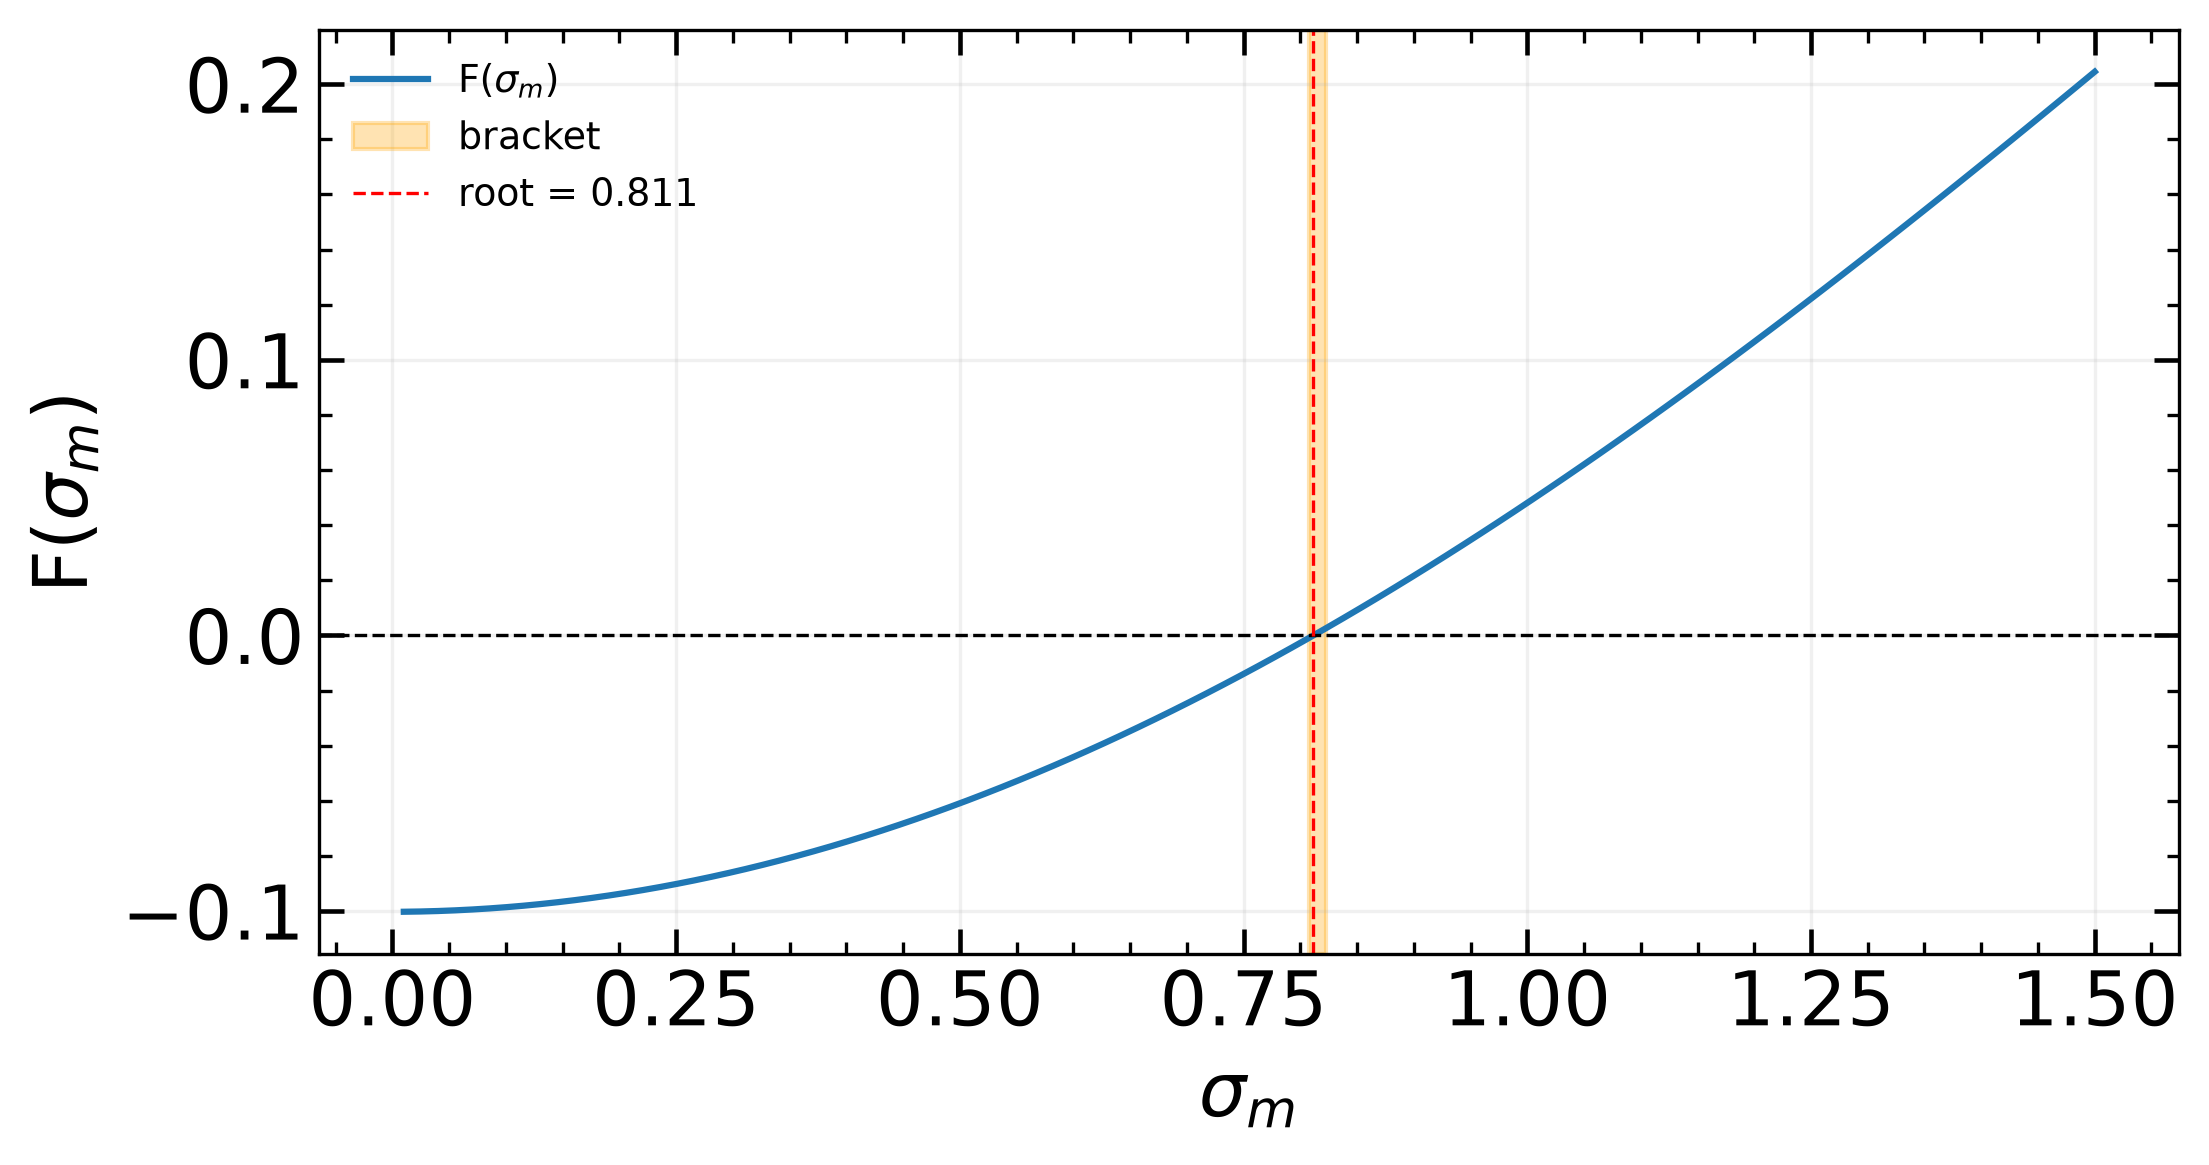

In [86]:
# plot
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.plot(sigma_space, F_vals, label=r'F($\sigma_m$)')
ax.axhline(0, color='k', ls = '--', lw=0.8)
ax.axvspan(sigma_lo, sigma_hi, color='orange', alpha=0.3, label='bracket')
ax.axvline(sigma_root, color='r', ls='--', lw = 0.8, label=f'root = {sigma_root:.3f}')

ax.set_xlabel(r'$\sigma_m$')
ax.set_ylabel(r'F($\sigma_m$)')

ax.legend(frameon=False, fontsize=9, loc="best")
plt.show()

Therefore, the uncertainty in $m$ has to be approximately 0.811 or larger before my analytic solution for the error over/underestimates the true error by 10%. 

# Q5

See the following two data sets, which contain recession velocities and distances from Lemaitre (1927) and Hubble (1929).


The object of this exercise is to establish "who discovered the distance-redshift relation".

For each dataset, determine:

---

1. The <mark>Pearson product-moment correlation coefficient</mark> and its <mark>error</mark>, and the <mark>statistical significance</mark> of the correlation.

2. The Spearman rank cross-correlation coefficient and its statistical significance.

---

3. Linear least-squares regression lines of the form:
$$
V = HD
$$

    1. Starting from the notes or text, _derive_ an equation from first prinmciples for the best-fit slope $H$ and apply your equation to the data (i.e. do not use a built in fitting routine)

    2. Assuming that all the scatter is due to measurement errors in the velocity $V$, estimate these measurement errors (you may assume they are homoskedastic).

    3. Given the above, derive an expression for the uncertainty in the slope and apply it to the data. Apply your equation.

    4. Print the $H$, its uncertainty and the scatter around the fit.

    5. Plot the best fit as line with a shaded band indicating the $\pm1 \sigma$ uncertainties.

---

4. Now assume that the uncertainty is all in the measurements of $D$. Fit 

$$
D  = \frac{V}{H^{\sim}}
$$

Print $H^{\sim}$, its uncertainty and the scatter in $D$ around the best fit. Plot this on the same diagram as the previous line. 

Does $H^{\sim} = H$? Why or why not? If not, which one do you think is correct?

---

5. Linear least-squares regression lines of the form:
$$
V = H' D + C \; .
$$

You can fit this with a standard piece of code (e.g. polyfit)

Plot the best fit line and a shaded shape showing the uncertainty in the predicted value of the dependent variable over the entitre range spanned by the independent variable. Note this shape will not be linear!

Where is this shaded region thinnest? Is there anything special about this location?

Print the slope and intercept with uncertainties, and the scatter around the fit.

---

Who do you believe should be credited with the discovery of a linear redshift-distance relation? Justify your answer.


#### data

In [26]:
# Put the data into astropy tables

lemaitre_data_str = """# Lemaitre 1927 data
# Distance D is in Mpc and Velocity V is in km/s
# D   V
0.63 -300
0.11 -315
2.75  650
1.82  -25
1.66 1800
0.28  -70
1.82 1300
1.20  300
0.72  916
3.47  800
1.51  700
1.05  400
0.83  600
0.50  -30
0.69  290
0.87  600
1.10  940
0.83  812
1.91  600
1.15  730
1.05  800
0.72  650
1.15  800
2.75  950
2.00  300
0.60  500
1.10  500
0.87  200
0.63  850
0.95  800
1.82  580
1.74 1100
0.72 1140
0.87 1090
0.52  290
0.69  150
1.82  900
0.91  450
0.33  240
1.32  500
2.40  650
1.32  500
"""

import astropy.table

# read from the string as if it were a file
lemaitre = astropy.table.Table.read(lemaitre_data_str,
                                    format='ascii.commented_header',
                                    header_start=-1)

hubble_data_str="""# Hubble's 1929 data
# Distance D is in Mpc and Velocity V is in km/s 
#D     V
0.032  170
0.03   290
0.214 -130
0.263  -70
0.275 -185
0.275 -220
0.45   200
0.5    290
0.5    270
0.63   200
0.8    300
0.9    -30
0.9    650
0.9    150
0.9    500
1.0    920
1.1    450
1.1    500
1.4    500
1.7    960
2.0    500
2.0    850
2.0    800
2.0   1090
"""

hubble = astropy.table.Table.read(hubble_data_str,
                                  format='ascii.commented_header',
                                  header_start=-1)

In [27]:
hubble # print it to illustrate the data

D,V
float64,int64
0.032,170
0.03,290
0.214,-130
0.263,-70
0.275,-185
0.275,-220
0.45,200
0.5,290
0.5,270


#### 1) Pearson product-moment correlation coefficient, error, and statistical significance


\begin{equation*}
    r = \frac{\sum_i (D_i - \bar{D})(V_i - \bar{V})}{\sqrt{\sum_i (D_i - \bar{D})^2 \sum_i (V_i - \bar{V})^2}}.
\end{equation*}

According to [stats.libretexts.org](https://stats.libretexts.org/Bookshelves/Applied_Statistics/Mikes_Biostatistics_Book_(Dohm)/16%3A_Correlation_Similarity_and_Distance/16.1%3A_Product-moment_correlation), the standard error of the correlation is: 
\begin{equation*}
    \sigma_r = \sqrt{\frac{1-r^2}{N-2}}
\end{equation*}

and from the notes the significance of Pearson's $r$ is the $t$ value:

\begin{equation*}
    t = r \sqrt{\frac{N-2}{1-r^2}}
\end{equation*}


In [112]:
from scipy.stats import pearsonr

print(f"--------- 1. ----------")

for name, data in [("Lemaître", lemaitre), ("Hubble", hubble)]:
    N = len(data)
    r, p_value = pearsonr(data["D"], data["V"])

    sigma_r = np.sqrt((1 - r**2) / (N - 2))

    print(f"{name}:")
    print(f"  r = {r:.3f} ± {sigma_r:.3f}")
    print(f"  p = {p_value:.3e}")

--------- 1. ----------
Lemaître:
  r = 0.381 ± 0.146
  p = 1.290e-02
Hubble:
  r = 0.789 ± 0.131
  p = 4.526e-06


Both datasets show a positive correlation significant at the 5% level, with substantially stronger evidence in Hubble’s dataset ($p$ value 4 orders of magnitude smaller).

#### 2) Spearman Rank correlation

In [ ]:
from scipy.stats import spearmanr

print(f"--------- 2. ----------")
for name, data in [("Lemaître", lemaitre), ("Hubble", hubble)]:
    r_s, p_value = spearmanr(data["D"], data["V"])

    print(f"{name}")
    print(f"  r_s = {r_s:.3f}")
    print(f"  p = {p_value:.3e}")

--------- 2. ----------
Lemaître
  r_s = 0.417
  p = 6.004e-03
Hubble
  r_s = 0.796
  p = 3.360e-06


Both datasets show a positive correlation significant at the 5% level, with substantially stronger evidence in Hubble’s dataset once again ($p$ value 3 orders of magnitude smaller).

#### 3) Linear least-squares regression

We fit a line through the origin,
\begin{equation*}
V = H D
\end{equation*}
assuming exact distances and independent velocity errors with zero mean
and a common variance $\sigma_V^2$.

The least-squares estimate minimizes
\begin{equation*}
f(H) = \sum_{i=1}^{N}(V_i - H D_i)^2
\end{equation*}

Differentiating with respect to $H$ and setting the derivative to zero
\begin{align*}
\frac{df}{dH}
&= -2\sum_{i=1}^{N}D_i(V_i - H D_i) = 0 \\
\sum_{i=1}^{N}D_iV_i
&= H\sum_{i=1}^{N}D_i^2
\end{align*}

\begin{equation*}
\boxed{H_{\rm min} = \frac{\sum_{i=1}^{N}D_iV_i}{\sum_{i=1}^{N}D_i^2}}
\end{equation*}

Check this is indeed a minimum:
\begin{equation*}
\frac{d^2S}{dH^2} = 2\sum_{i=1}^{N}D_i^2 > 0
\end{equation*}

We estimate the common velocity variance from the residuals:
\begin{equation*}
s_V^2 = \frac{1}{N-1}\sum_{i=1}^{N}(V_i-H_{\rm min}D_i)^2.
\end{equation*}
There are $N-1$ residual degrees of freedom because we fitted one
parameter only. Therefore the estimated scatter in velocity is
\begin{equation*}
\boxed{s_V = \sqrt{\frac{\sum_{i=1}^{N}(V_i-H_{\rm min}D_i)^2}{N-1}}}.
\end{equation*}

To obtain the uncertainty in the slope, write $H_{\rm min}$ as a linear
combination of the measured velocities:
\begin{equation*}
H_{\rm min} = \sum_{i=1}^{N}
\left(\frac{D_i}{\sum_{j=1}^{N}D_j^2}\right)V_i.
\end{equation*}

Since the velocity errors are independent, their variance contributions
add:
\begin{align*}
\operatorname{Var}(H_{\rm min})
&= \sum_{i=1}^{N}
\left(\frac{D_i}{\sum_{j=1}^{N}D_j^2}\right)^2\sigma_V^2 \\
&= \frac{\sigma_V^2\sum_{i=1}^{N}D_i^2}
{\left(\sum_{j=1}^{N}D_j^2\right)^2} \\
&= \frac{\sigma_V^2}{\sum_{i=1}^{N}D_i^2}.
\end{align*}

Substituting $s_V$ for the unknown $\sigma_V$, the estimated standard
error of the slope is
\begin{equation*}
\boxed{s_H = \frac{s_V}{\sqrt{\sum_{i=1}^{N}D_i^2}}}.
\end{equation*}

At any fixed distance $D$, the fitted velocity is
${V}(D)={H}D$, with standard error
\begin{equation*}
s_{{V}}(D)=|D|s_H.
\end{equation*}

Therefore, the shaded $\pm1\sigma$ uncertainty band for the fitted line is
\begin{equation*}
\boxed{{V}(D)\pm s_{{V}}(D)={H}D\pm |D|s_H}.
\end{equation*}
This describes uncertainty in the fitted line, rather than the scatter
of individual velocity measurements.

--------- 3. ----------


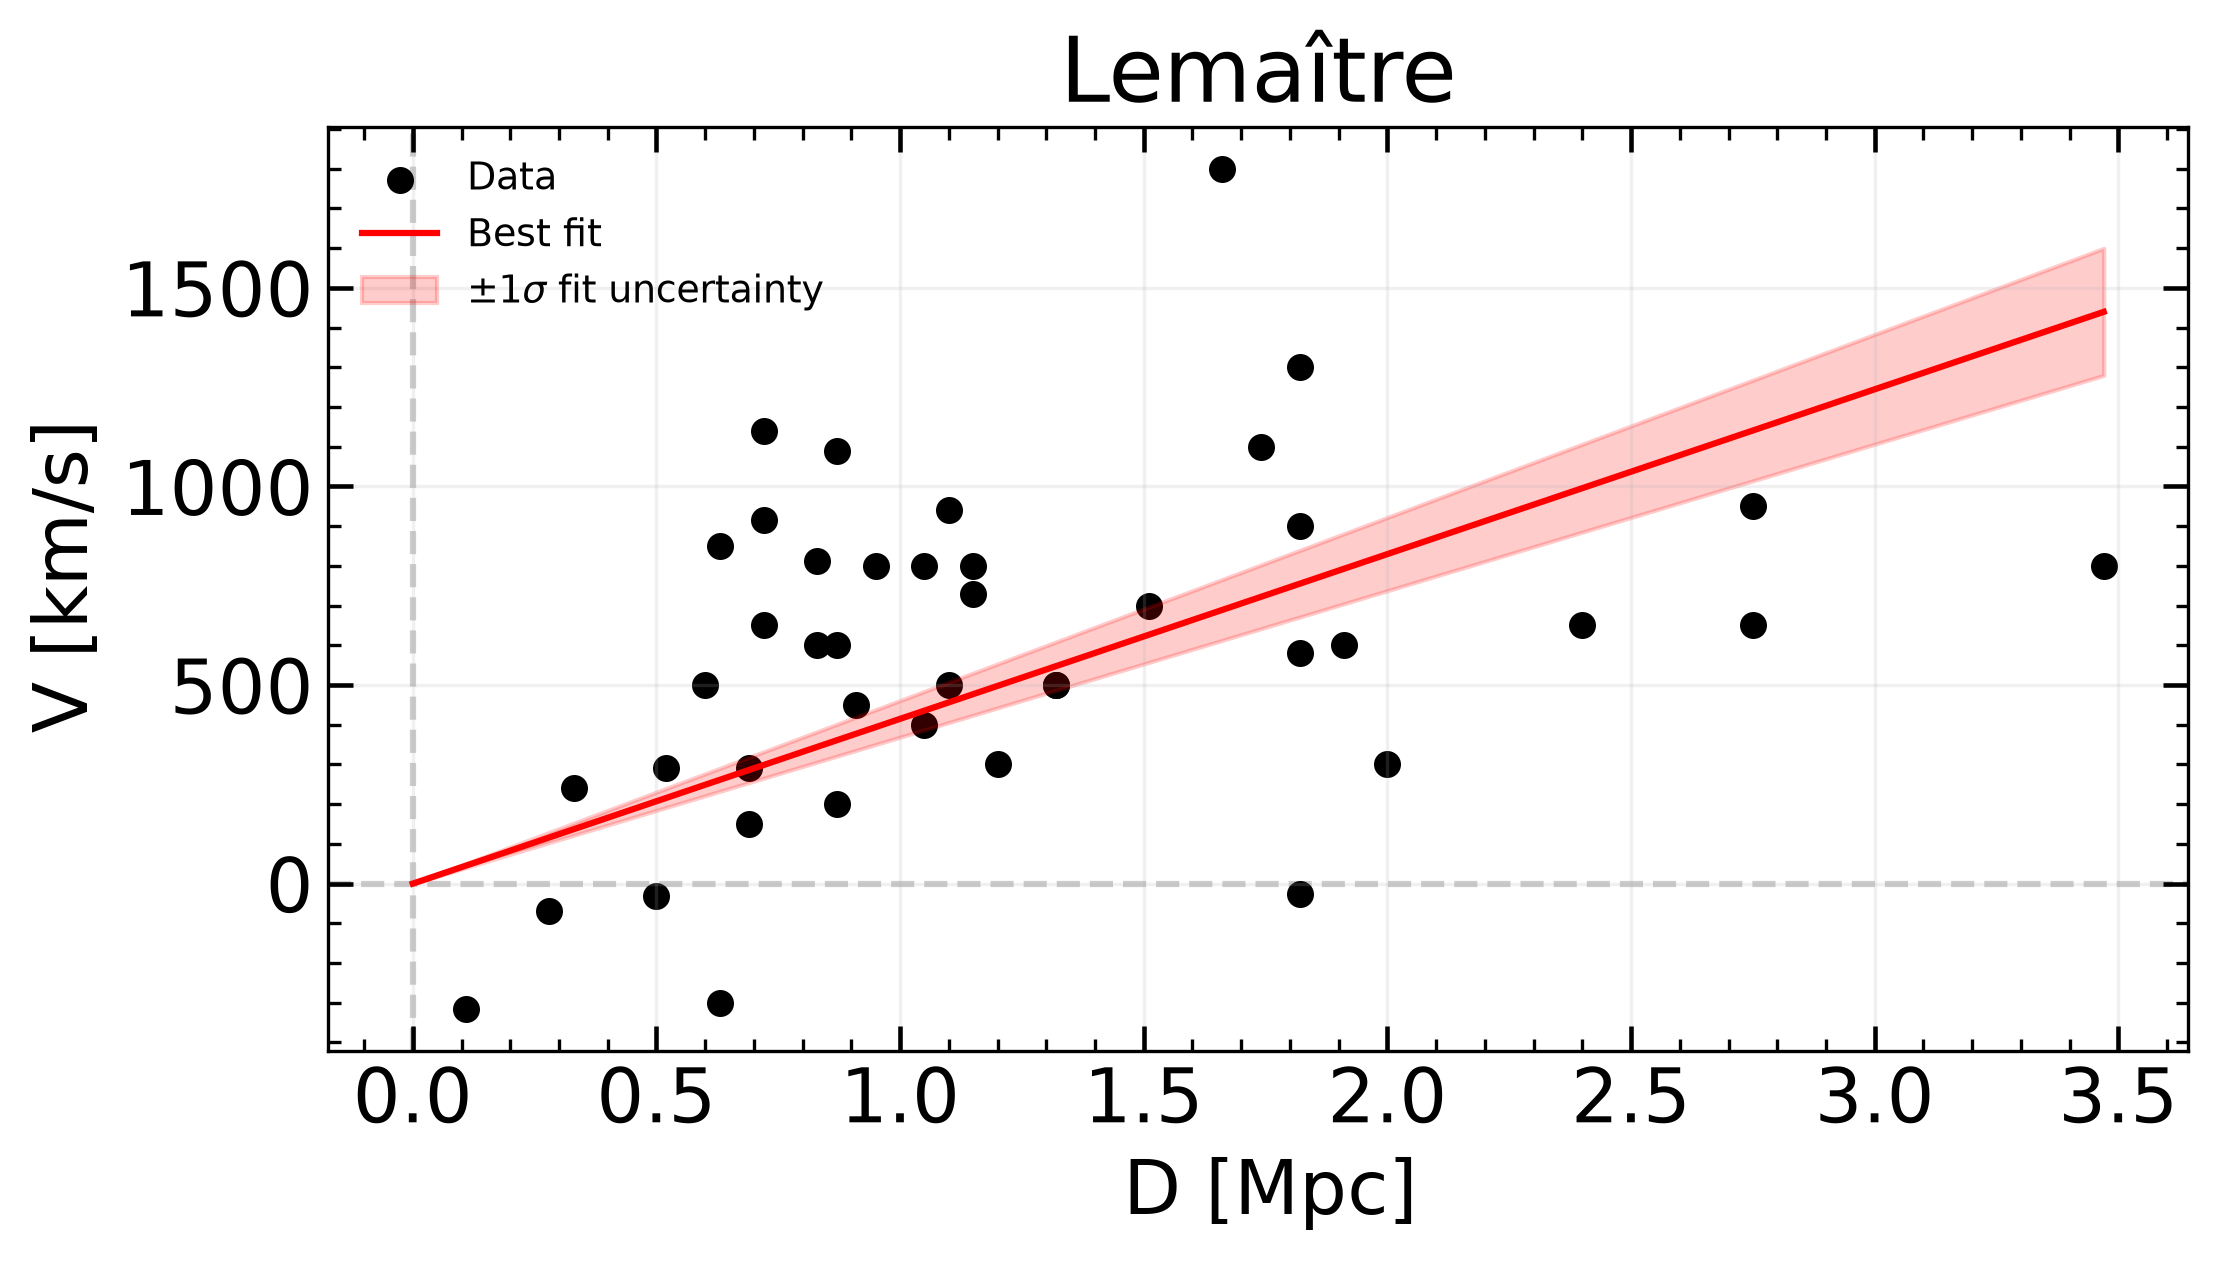

Lemaître:
  H = 414.9 ± 46.1 km/s/Mpc
  Scatter in V = 422.2 km/s


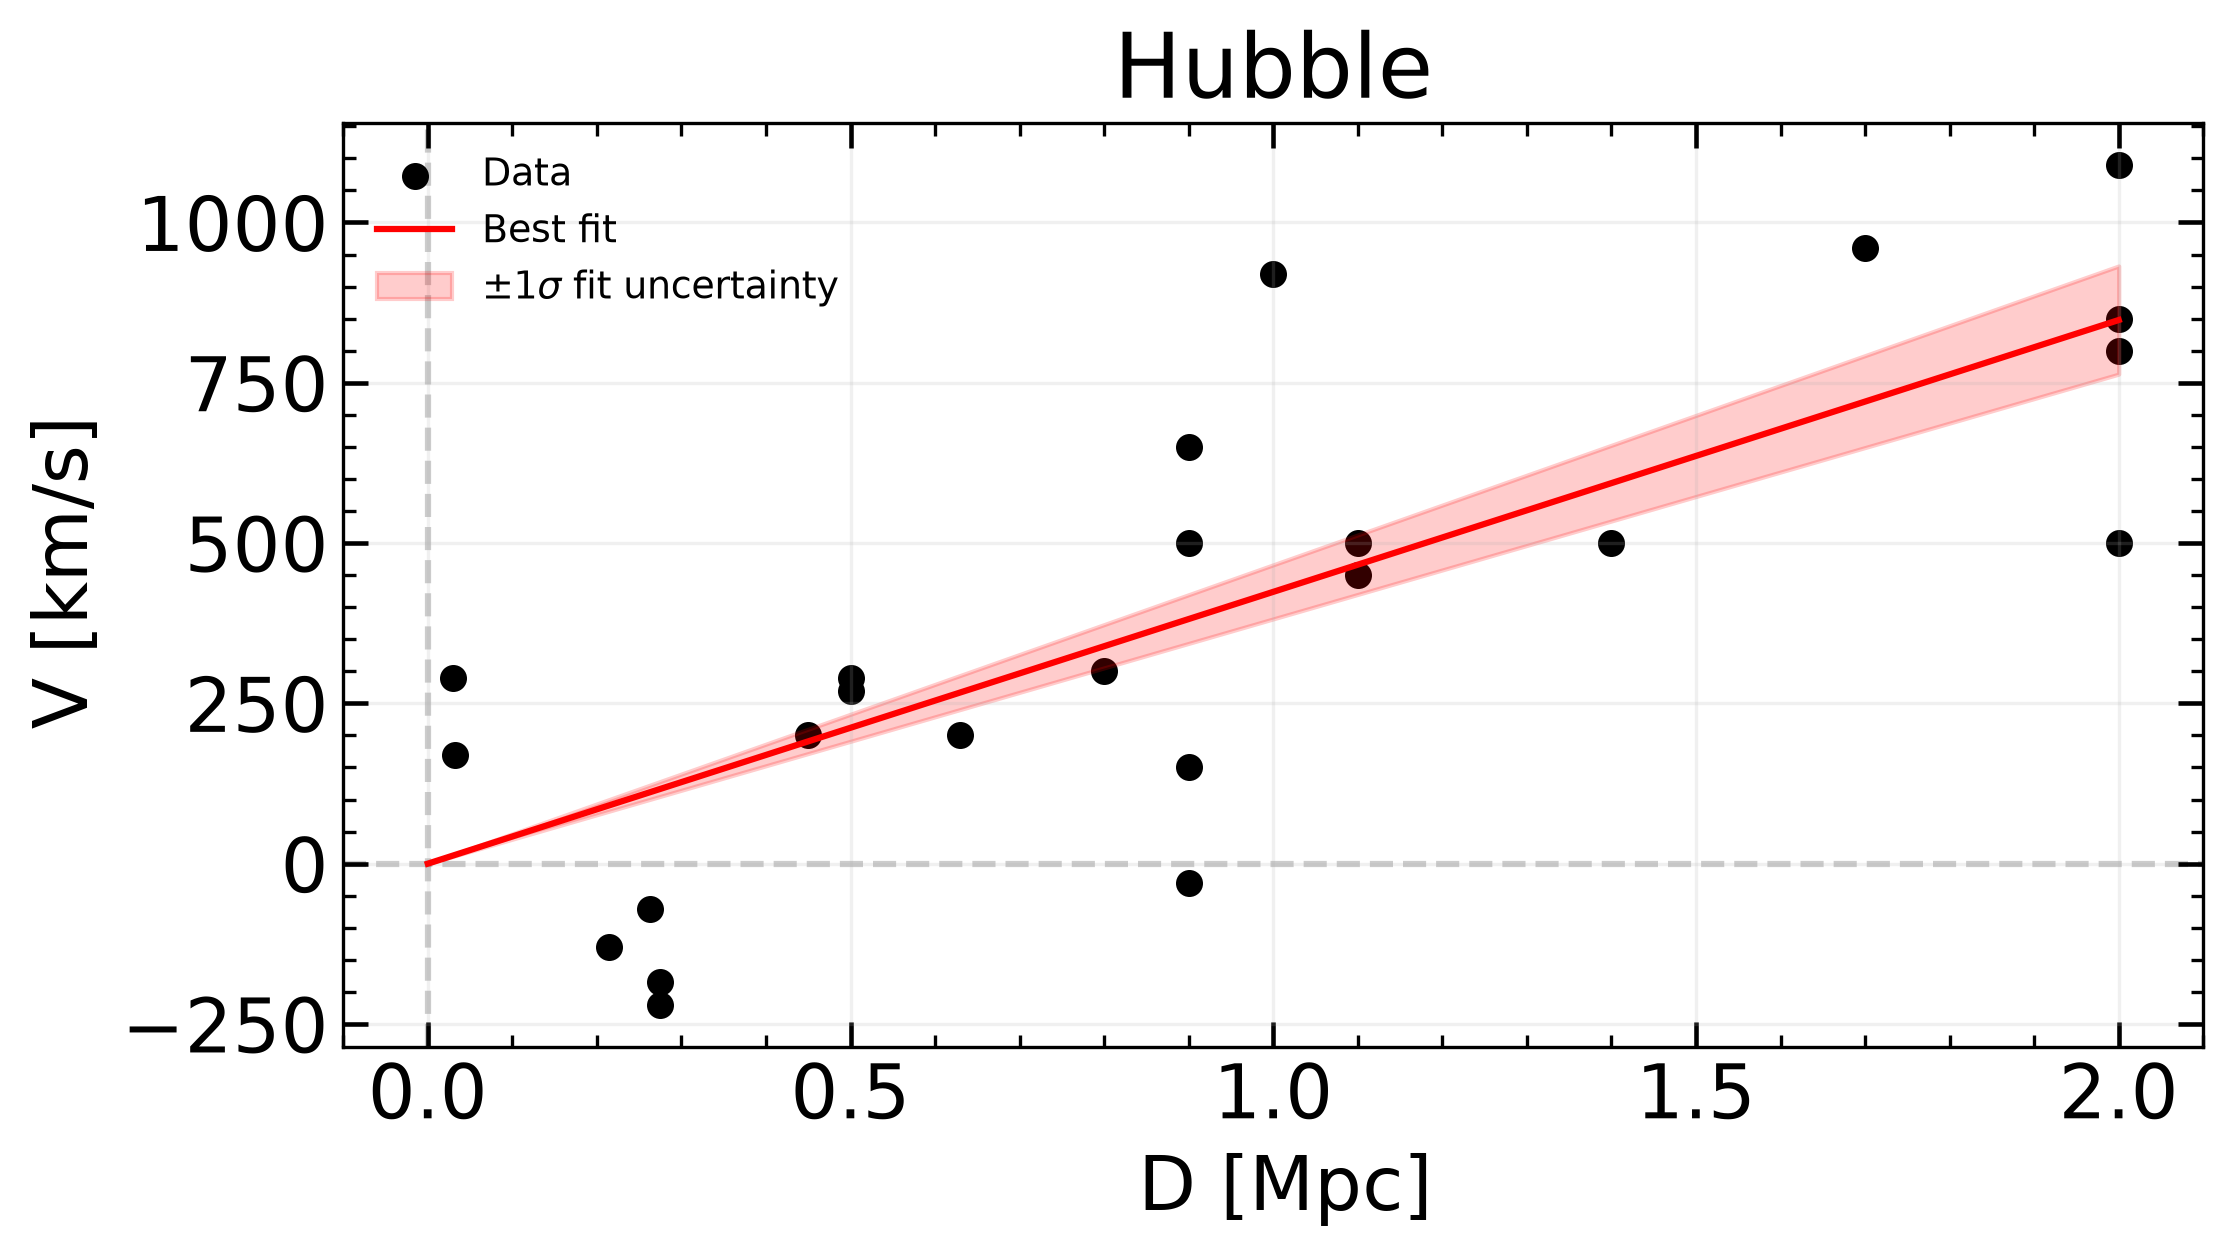

Hubble:
  H = 423.9 ± 42.2 km/s/Mpc
  Scatter in V = 229.1 km/s


In [137]:
print("--------- 3. ----------")

for name, data in [("Lemaître", lemaitre), ("Hubble", hubble)]:
    D = np.asarray(data["D"])
    V = np.asarray(data["V"])
    N = len(D)

    H = np.sum(D * V) / np.sum(D**2)

    residuals = V - H * D
    sigma_V = np.sqrt(np.sum(residuals**2) / (N - 1))
    sigma_H = sigma_V / np.sqrt(np.sum(D**2))


    D_line = np.linspace(0, D.max(), 200)
    V_line = H * D_line

    fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
    # ticks on all four sides
    ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
    ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, which="major", alpha=0.18, lw=0.8)

    plt.scatter(D, V, label="Data", color = "black", s = 30.0)
    plt.plot(D_line, V_line, color="red", label="Best fit")
    plt.fill_between(
        D_line,
        V_line - sigma_H * D_line,
        V_line + sigma_H * D_line,
        color="red", alpha=0.2,
        label=r"$\pm 1\sigma$ fit uncertainty"
    )

    ax.axhline(0, color = 'black', alpha = 0.2, ls = 'dashed', zorder = -3)
    ax.axvline(0, color = 'black', alpha = 0.2, ls = 'dashed', zorder = -3)

    ax.set_xlabel(" D [Mpc]")
    ax.set_ylabel(" V [km/s]")
    ax.set_title(name)
    ax.legend(frameon=False, fontsize=9, loc="best")
    plt.show()

    print(f"{name}:")
    print(f"  H = {H:.1f} ± {sigma_H:.1f} km/s/Mpc")
    print(f"  Scatter in V = {sigma_V:.1f} km/s")

#### 4) Uncertainty all in the measurements of $D$

We now assume exact velocities and independent distance errors with zero
mean and a common variance $\sigma_D^2$. The model is
\begin{equation*}
D = \frac{V}{\widetilde{H}} = bV,
\qquad b = \frac{1}{\widetilde{H}}.
\end{equation*}

The least-squares estimate minimizes
\begin{equation*}
f(b) = \sum_{i=1}^{N}(D_i-bV_i)^2.
\end{equation*}

Differentiating with respect to $b$ and setting the derivative to zero,
\begin{align*}
\frac{df}{db}
&= -2\sum_{i=1}^{N}V_i(D_i-bV_i) = 0, \\
\sum_{i=1}^{N}V_iD_i
&= b\sum_{i=1}^{N}V_i^2.
\end{align*}

Therefore,
\begin{equation*}
\boxed{b_{\rm min} =
\frac{\sum_{i=1}^{N}V_iD_i}{\sum_{i=1}^{N}V_i^2}},
\qquad
\boxed{\widetilde{H} = \frac{1}{b_{\rm min}} =
\frac{\sum_{i=1}^{N}V_i^2}{\sum_{i=1}^{N}V_iD_i}}.
\end{equation*}

This is a minimum because
\begin{equation*}
\frac{d^2f}{db^2} = 2\sum_{i=1}^{N}V_i^2 > 0.
\end{equation*}

We estimate the common distance uncertainty from the residuals:
\begin{equation*}
\boxed{s_D =
\sqrt{\frac{\sum_{i=1}^{N}(D_i-b_{\rm min}V_i)^2}{N-1}}}.
\end{equation*}
There are $N-1$ residual degrees of freedom because we fitted one
parameter.

Since $b_{\rm min}$ is a linear combination of the independent
distance measurements,
\begin{align*}
\operatorname{Var}(b_{\rm min})
&= \sum_{i=1}^{N}
\left(\frac{V_i}{\sum_{j=1}^{N}V_j^2}\right)^2\sigma_D^2 \\
&= \frac{\sigma_D^2}{\sum_{i=1}^{N}V_i^2}.
\end{align*}

Substituting $s_D$ for the unknown $\sigma_D$, the estimated standard
error in $b$ is
\begin{equation*}
\boxed{s_b = \frac{s_D}{\sqrt{\sum_{i=1}^{N}V_i^2}}}.
\end{equation*}

Propagating this uncertainty through $\widetilde{H}=1/b$ gives
\begin{equation*}
\boxed{s_{\widetilde{H}} \approx
\left|\frac{d(1/b)}{db}\right|_{b=b_{\rm min}}s_b
= \frac{s_b}{b_{\rm min}^2}}.
\end{equation*}

--------- 4. ----------


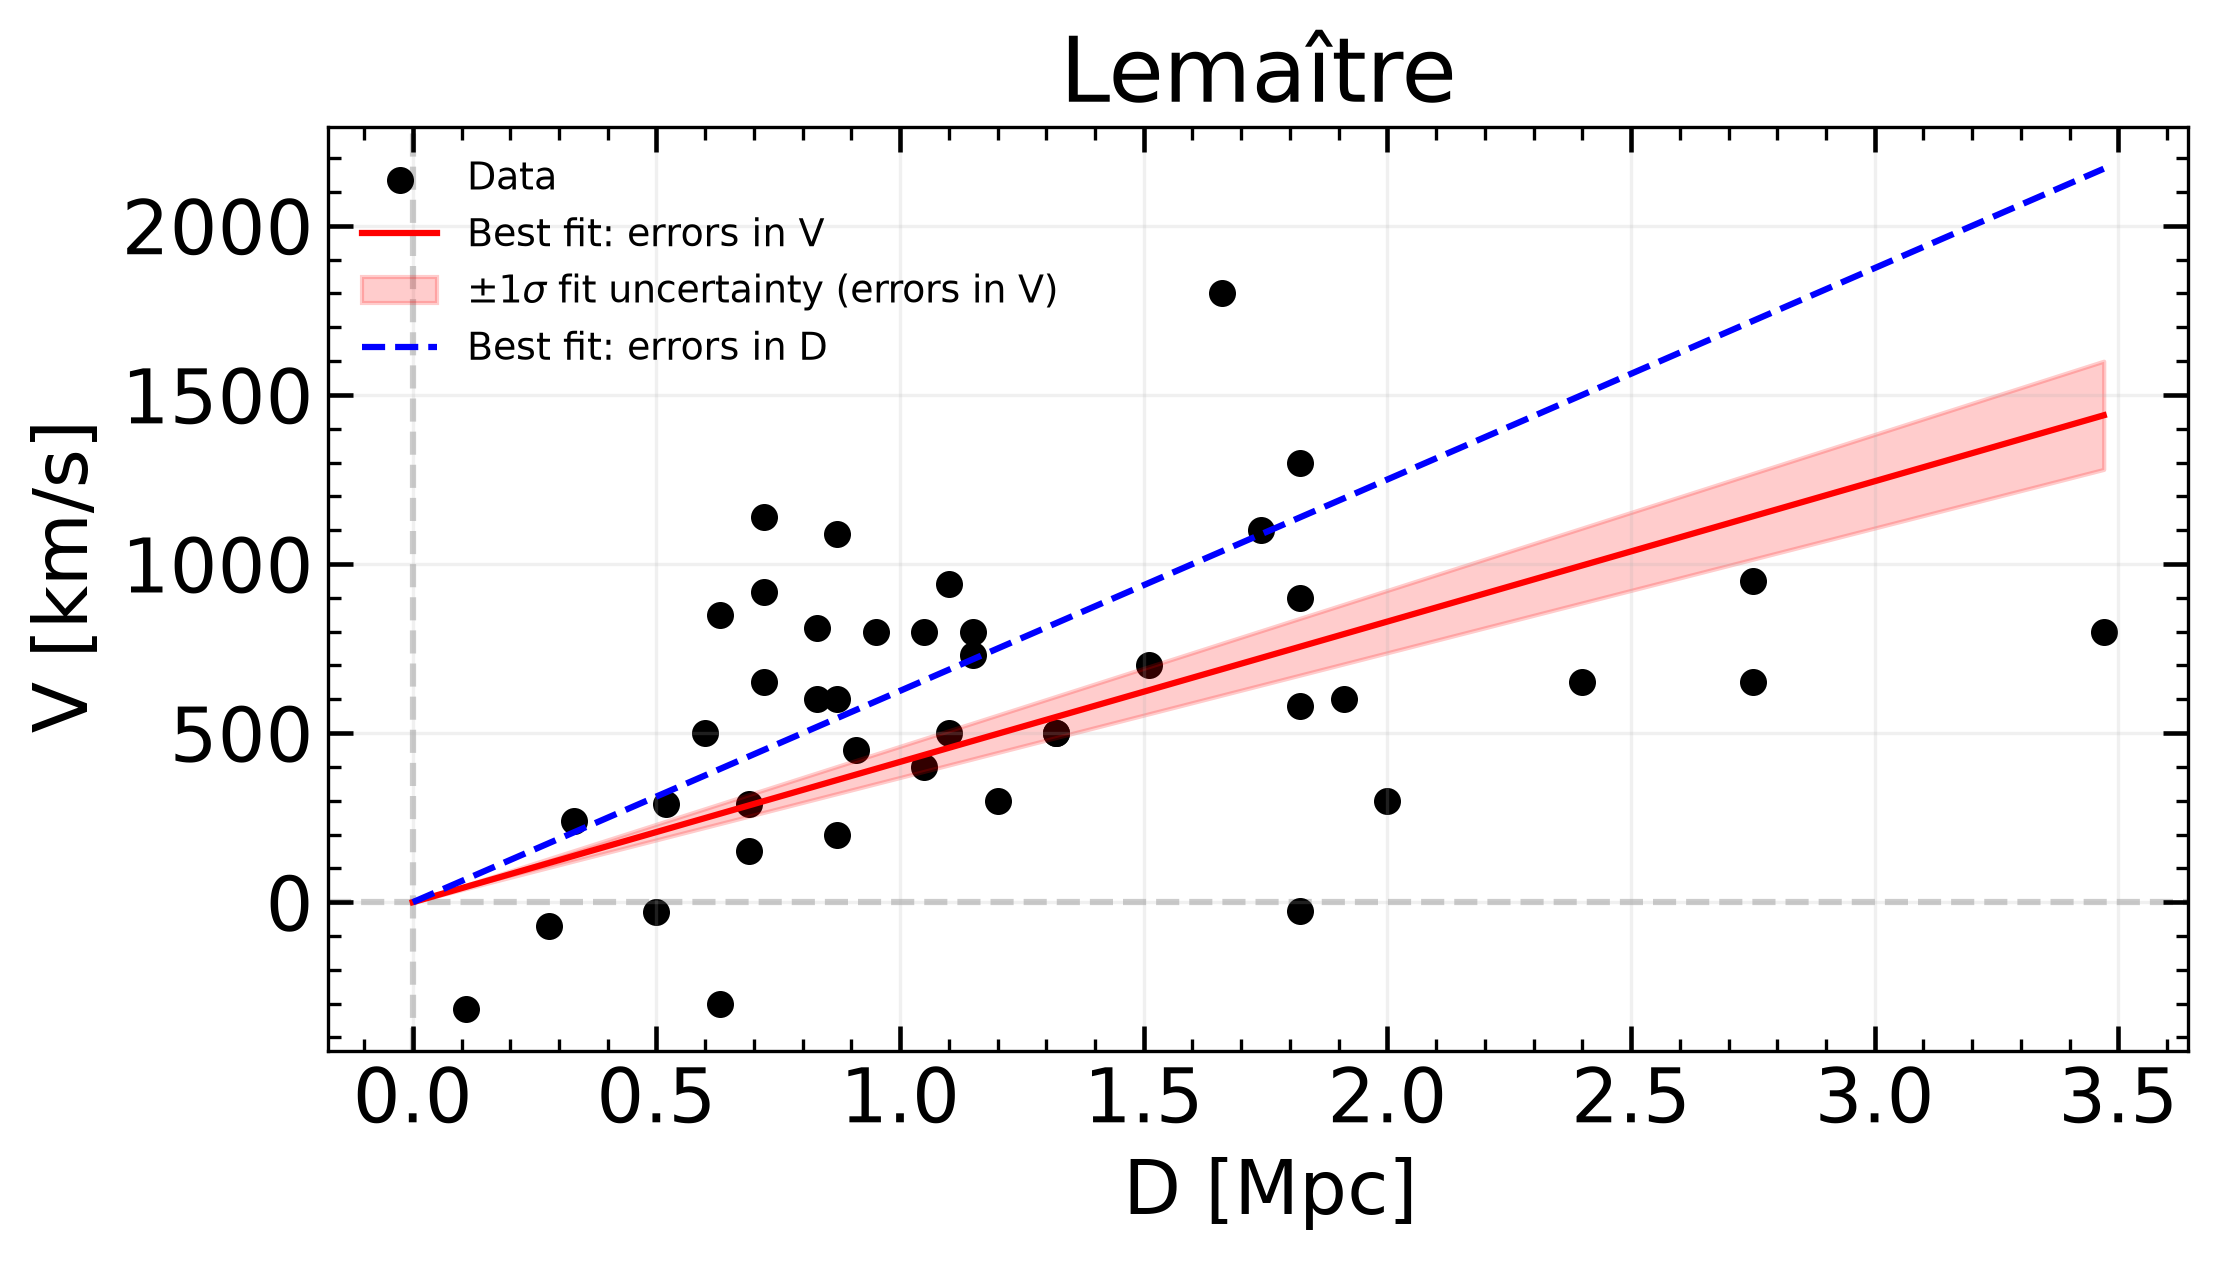

Lemaître:
  H = 414.9 ± 46.1 km/s/Mpc
  H_tilde = 624.9 ± 69.5 km/s/Mpc
  Scatter in D = 0.829 Mpc


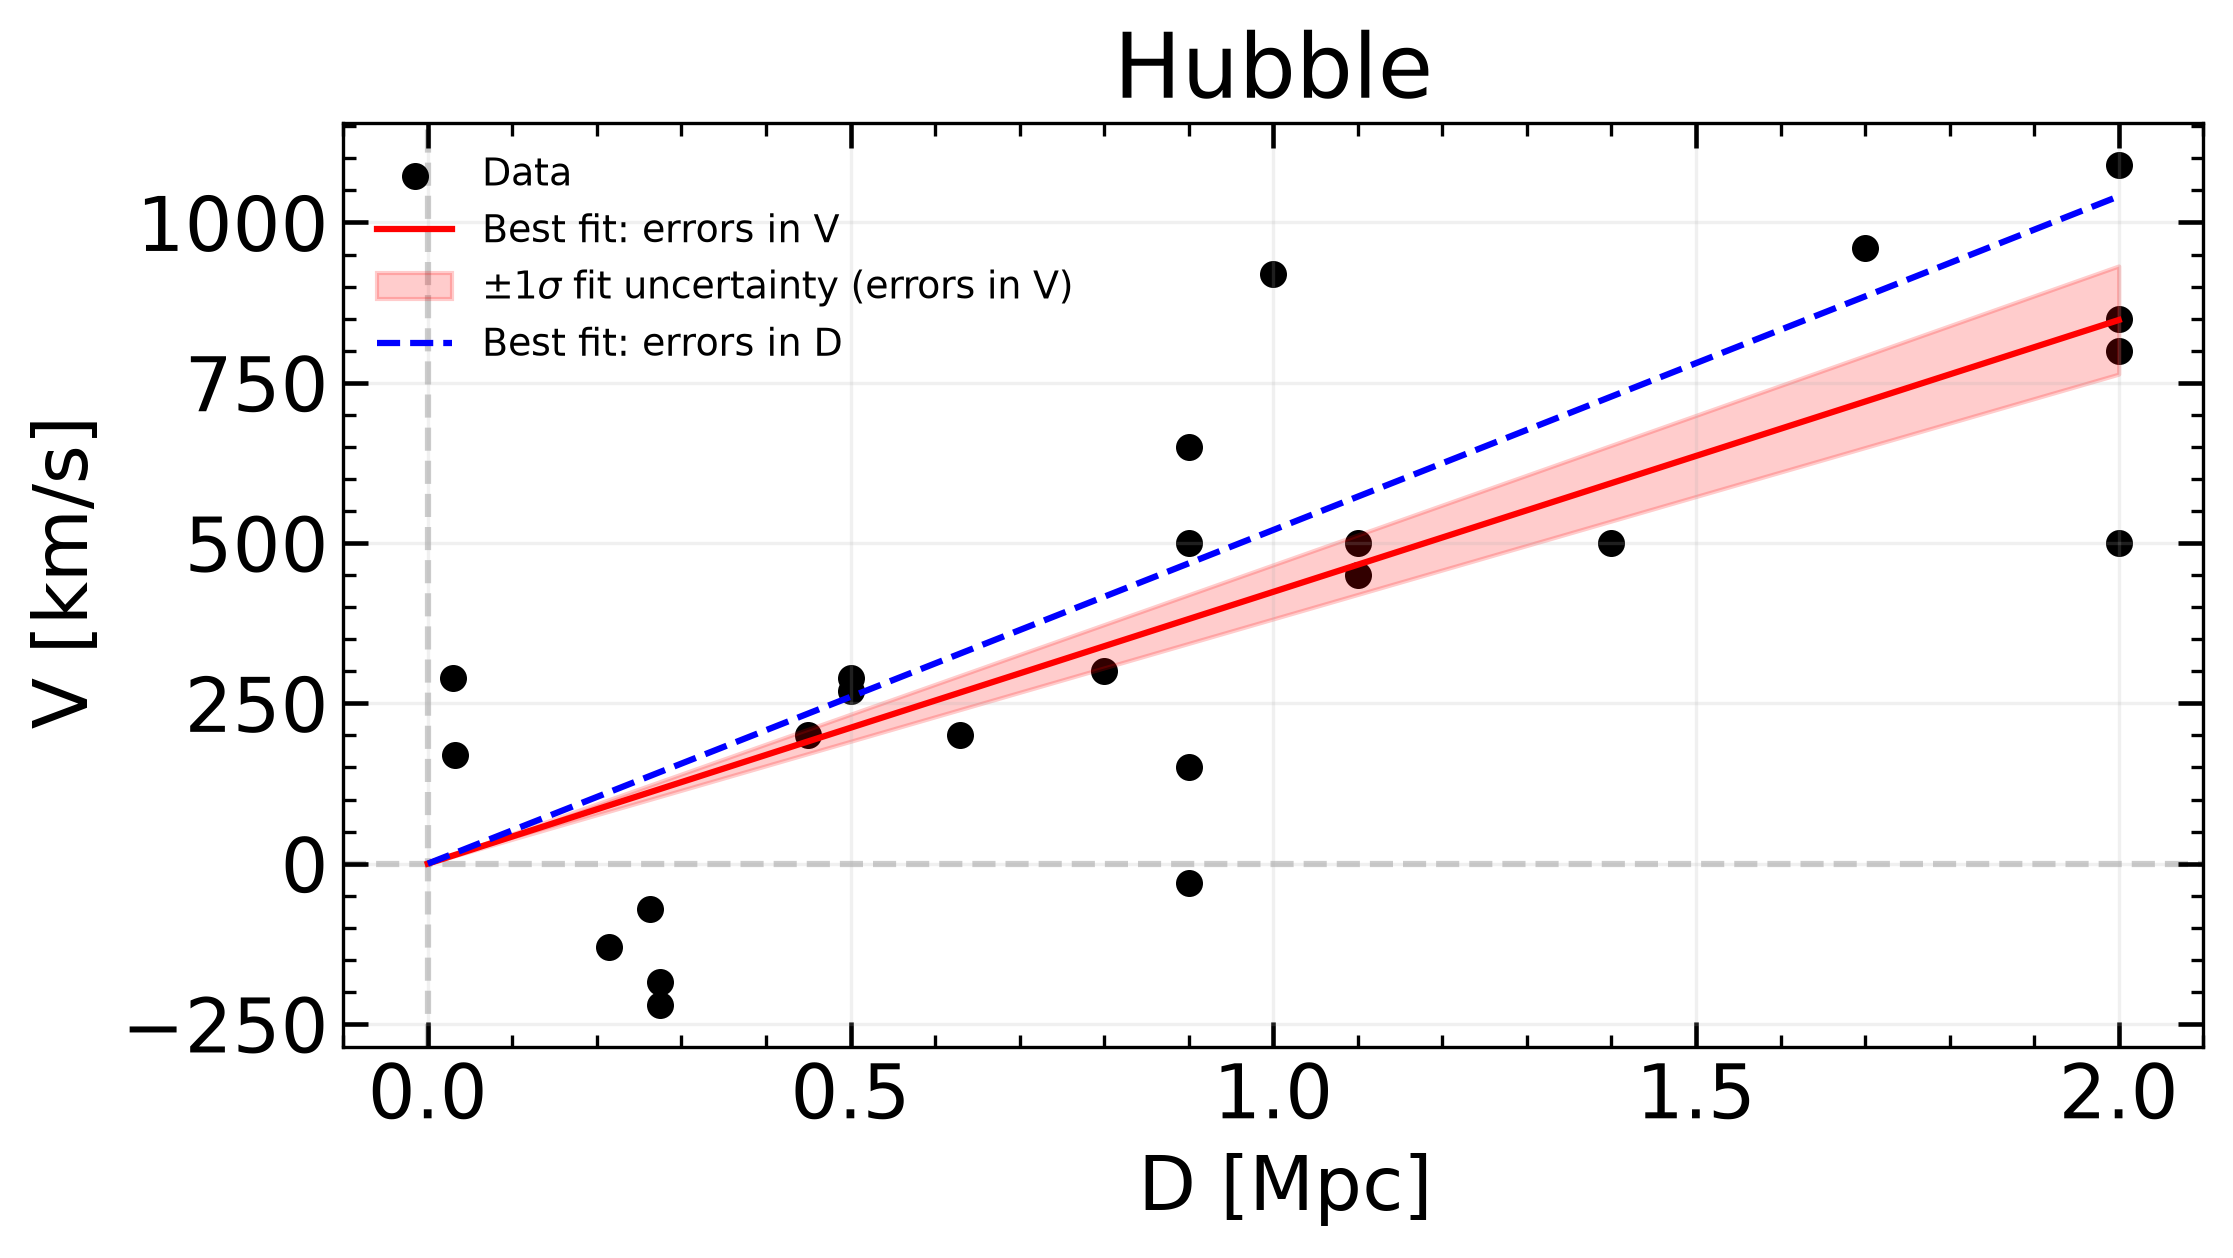

Hubble:
  H = 423.9 ± 42.2 km/s/Mpc
  H_tilde = 520.4 ± 51.8 km/s/Mpc
  Scatter in D = 0.488 Mpc


In [140]:
print("--------- 4. ----------")

for name, data in [("Lemaître", lemaitre), ("Hubble", hubble)]:
    D = np.asarray(data["D"])
    V = np.asarray(data["V"])
    N = len(D)

    # Part 3: uncertainty in V
    H = np.sum(D * V) / np.sum(D**2)

    residuals = V - H * D
    sigma_V = np.sqrt(np.sum(residuals**2) / (N - 1))
    sigma_H = sigma_V / np.sqrt(np.sum(D**2))

    # Part 4: uncertainty in D, fitting D = bV
    b = np.sum(V * D) / np.sum(V**2)

    residuals_D = D - b * V
    sigma_D = np.sqrt(np.sum(residuals_D**2) / (N - 1))
    sigma_b = sigma_D / np.sqrt(np.sum(V**2))

    H_tilde = 1 / b
    sigma_H_tilde = sigma_b / b**2

    D_line = np.linspace(0, D.max(), 200)
    V_line = H * D_line
    V_line_tilde = H_tilde * D_line

    fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
    # ticks on all four sides
    ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
    ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, which="major", alpha=0.18, lw=0.8)

    plt.scatter(D, V, label="Data", color = "black", s = 30.0)
    plt.plot(D_line, V_line, color="red", label="Best fit: errors in V")
    plt.fill_between(
        D_line,
        V_line - sigma_H * D_line,
        V_line + sigma_H * D_line,
        color="red", alpha=0.2,
        label=r"$\pm 1\sigma$ fit uncertainty (errors in V)"
    )
    plt.plot(
        D_line, V_line_tilde,
        color="blue", ls="dashed",
        label="Best fit: errors in D"
    )

    ax.axhline(0, color='black', alpha=0.2, ls='dashed', zorder=-3)
    ax.axvline(0, color='black', alpha=0.2, ls='dashed', zorder=-3)

    ax.set_xlabel(" D [Mpc]")
    ax.set_ylabel(" V [km/s]")
    ax.set_title(name)
    ax.legend(frameon=False, fontsize=9, loc="best")
    plt.show()

    print(f"{name}:")
    print(f"  H = {H:.1f} ± {sigma_H:.1f} km/s/Mpc")
    print(f"  H_tilde = {H_tilde:.1f} ± {sigma_H_tilde:.1f} km/s/Mpc")
    print(f"  Scatter in D = {sigma_D:.3f} Mpc")

In general, $\widetilde{H}\neq H$. The fit in part 3 minimizes squared
velocity residuals, corresponding to vertical deviations on the $V$ against $D$ plot. The fit here minimizes squared distance residuals, corresponding to horizontal deviations instead.

Neither is completely correct. The correct would fit depend
on which measurement carries the uncertainty. $H$ assumes exact
distances, whereas $\widetilde{H}$ assumes exact velocities, and if both
quantities have non-negligeable measurement uncertainties, a model that
accounts for errors in both variables would be needed.